<a href="https://colab.research.google.com/github/TAMOSREE-SAHA/tama/blob/main/Assignment_8_Tamosree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 19. Homework Assignment

### 📝 Task: Superstore Profitability Prediction

**Dataset:** Superstore Sales

**Kaggle Link:** https://www.kaggle.com/datasets/himanshuuike/superstore-sales-dataset

**File:** `samplesuperstore.csv` (upload to `MyDrive/datasets/`)

**Target:** create `profit_class` from the profit margin (= Profit / Sales):

| Class | Rule |
|---|---|
| 0 – Loss | Profit < 0 |
| 1 – Low margin | margin < 0.25 |
| 2 – High margin | margin ≥ 0.25 |

---

### Tasks:

**Task 1: Load & Explore Data**
- Load the dataset from Google Drive
- Display first rows, `info()`, `describe()`

**Task 2: Clean Data**
- Create the `profit_class` target
- Keep features: Ship Mode, Segment, Region, Category, Sub-Category, Sales, Quantity, Discount
- Drop the `Profit` column

**Task 3: Preprocess**
- Encode text columns with `LabelEncoder`
- Stratified train/test split (80/20, `random_state=20`)

**Task 4: Train Models**
- Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, Stacking

**Task 5: Evaluate**
- Comparison table: accuracy, precision, recall, F1 (macro and weighted), ROC-AUC
- Classification report for every model

**Task 6: Visualize**
- Confusion matrix for every model
- ROC curve (one-vs-rest) + AUC for every model


---



In [1]:
# Install boosting libraries
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Ensemble models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 20   # same seed everywhere -> reproducible results

In [ ]:
# TASK 1: Load and Explore Data
# TODO: info(), describe(), correlation heatmap

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Dataset/samplesuperstore.csv')
df.head(3)

Mounted at /content/drive


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717


In [4]:
# Column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [5]:
# Summary statistics of numeric columns
df.describe().round(2)

,Row ID,Sales,Quantity,Discount,Profit
count,10194.00,10194.00,10194.00,10194.00,10194.00
mean,5097.50,228.23,3.79,0.16,28.67
std,2942.90,619.91,2.23,0.21,232.47
min,1.00,0.44,1.00,0.00,-6599.98
25%,2549.25,17.22,2.00,0.00,1.76
50%,5097.50,53.91,3.00,0.20,8.69
75%,7645.75,209.50,5.00,0.20,29.30
max,10194.00,22638.48,14.00,0.80,8399.98


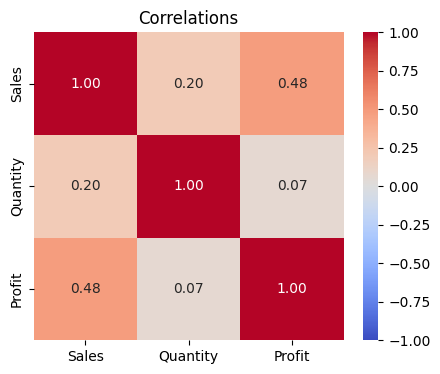

In [6]:
corr = df[['Sales', 'Quantity', 'Profit']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', ax=ax)
ax.set_title('Correlations')
plt.show()

In [7]:
# TASK 2: Clean Data

# TODO: Create profit_class (0 = Loss, 1 = Low margin, 2 = High margin)
# TODO: Keep the selected features + target
# TODO: Drop Profit


TARGET = "profit_class"
class_names = ["Loss", "Low margin", "High margin"]

margin = df["Profit"] / df["Sales"]
df[TARGET] = np.select([df["Profit"] < 0, margin < 0.25], [0, 1], default=2)

features = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category",
            "Sales", "Quantity", "Discount"]
df = df[features + [TARGET]].copy()

df = df.drop_duplicates()
df.head()

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,profit_class
0,Standard Class,Consumer,Central,Office Supplies,Paper,16.448,2,0.2,2
1,Standard Class,Home Office,Central,Office Supplies,Binders,3.540,2,0.8,0
2,Standard Class,Home Office,Central,Office Supplies,Labels,11.784,3,0.2,2
3,Standard Class,Home Office,Central,Office Supplies,Storage,272.736,3,0.2,0
4,Standard Class,Consumer,East,Office Supplies,Art,19.536,3,0.2,2


In [ ]:
# TASK 3: Preprocess

# TODO: Encode text columns
# TODO: Split data

In [8]:
# Features (X) and target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Convert text columns to numbers
for col in X.select_dtypes(exclude="number").columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X.head()

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount
0,3,0,0,1,12,16.448,2,0.2
1,3,2,0,1,3,3.540,2,0.8
2,3,2,0,1,10,11.784,3,0.2
3,3,2,0,1,14,272.736,3,0.2
4,3,0,1,1,2,19.536,3,0.2


In [9]:
# Stratified 80/20 split keeps class proportions equal in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples: 7805
Testing samples : 1952


In [ ]:
# TASK 4: Train Models

# TODO: Random Forest
# TODO: Extra Trees
# TODO: XGBoost
# TODO: LightGBM
# TODO: CatBoost
# TODO: Stacking

In [10]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)   # probabilities -> needed for ROC/AUC

print(f"Random Forest | accuracy = {accuracy_score(y_test, rf_pred):.4f}")

Random Forest | accuracy = 0.8432


In [11]:
# Extra Trees
et_model = ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
et_model.fit(X_train, y_train)

et_pred  = et_model.predict(X_test)
et_proba = et_model.predict_proba(X_test)

print(f"Extra Trees | accuracy = {accuracy_score(y_test, et_pred):.4f}")

Extra Trees | accuracy = 0.8202


In [12]:
# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=5,
                              random_state=RANDOM_STATE)
xgb_model.fit(X_train, y_train)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

print(f"XGBoost | accuracy = {accuracy_score(y_test, xgb_pred):.4f}")

XGBoost | accuracy = 0.8627


In [13]:
# LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=190, learning_rate=0.1, max_depth=5,
                               random_state=RANDOM_STATE, verbose=-1)
lgb_model.fit(X_train, y_train)

lgb_pred  = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)

print(f"LightGBM | accuracy = {accuracy_score(y_test, lgb_pred):.4f}")

LightGBM | accuracy = 0.8658


In [14]:
# CatBoost
cat_model = CatBoostClassifier(iterations=150, learning_rate=0.1, depth=5,
                               random_state=RANDOM_STATE, verbose=0)
cat_model.fit(X_train, y_train)

cat_pred  = cat_model.predict(X_test).ravel().astype(int)   # flatten to 1-D labels
cat_proba = cat_model.predict_proba(X_test)

print(f"CatBoost | accuracy = {accuracy_score(y_test, cat_pred):.4f}")

CatBoost | accuracy = 0.8566


In [15]:
# Stacking: 5 base models + Logistic Regression as the meta-model
stack_model = StackingClassifier(
    estimators=[("rf", rf_model), ("et", et_model), ("xgb", xgb_model),
                ("lgb", lgb_model), ("cat", cat_model)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
)
stack_model.fit(X_train, y_train)

stack_pred  = stack_model.predict(X_test)
stack_proba = stack_model.predict_proba(X_test)

print(f"Stacking | accuracy = {accuracy_score(y_test, stack_pred):.4f}")

Stacking | accuracy = 0.8612


In [ ]:
# TASK 5: Evaluate

# TODO: Comparison table
# TODO: Classification reports

In [17]:
models = {
    "Random Forest": (rf_pred, rf_proba),
    "Extra Trees":   (et_pred, et_proba),
    "XGBoost":       (xgb_pred, xgb_proba),
    "LightGBM":      (lgb_pred, lgb_proba),
    "CatBoost":      (cat_pred, cat_proba),
    "Stacking":      (stack_pred, stack_proba),
}

rows = []
for name, (pred, proba) in models.items():
    rows.append({
        "Model":                name,
        "Accuracy":             accuracy_score(y_test, pred),
        "Precision (macro)":    precision_score(y_test, pred, average="macro"),
        "Recall (macro)":       recall_score(y_test, pred, average="macro"),
        "F1 (macro)":           f1_score(y_test, pred, average="macro"),
        "Precision (weighted)": precision_score(y_test, pred, average="weighted"),
        "Recall (weighted)":    recall_score(y_test, pred, average="weighted"),
        "F1 (weighted)":        f1_score(y_test, pred, average="weighted"),
        "ROC-AUC":              roc_auc_score(y_test, proba, multi_class="ovr", average="macro"),
    })

results = pd.DataFrame(rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
best_model = results.iloc[0]["Model"]
results.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),ROC-AUC
0,LightGBM,0.8658,0.8446,0.8385,0.8414,0.8657,0.8658,0.8657,0.9670
1,XGBoost,0.8627,0.8395,0.8352,0.8373,0.8620,0.8627,0.8623,0.9658
2,Stacking,0.8612,0.8460,0.8275,0.8358,0.8622,0.8612,0.8611,0.9648
3,CatBoost,0.8566,0.8462,0.8193,0.8306,0.8594,0.8566,0.8567,0.9638
4,Random Forest,0.8432,0.8232,0.8129,0.8178,0.8437,0.8432,0.8433,0.9540
5,Extra Trees,0.8202,0.7969,0.7870,0.7917,0.8196,0.8202,0.8197,0.9344


In [ ]:
# TASK 6: Visualize

# TODO: Confusion matrices
# TODO: ROC curves + AUC

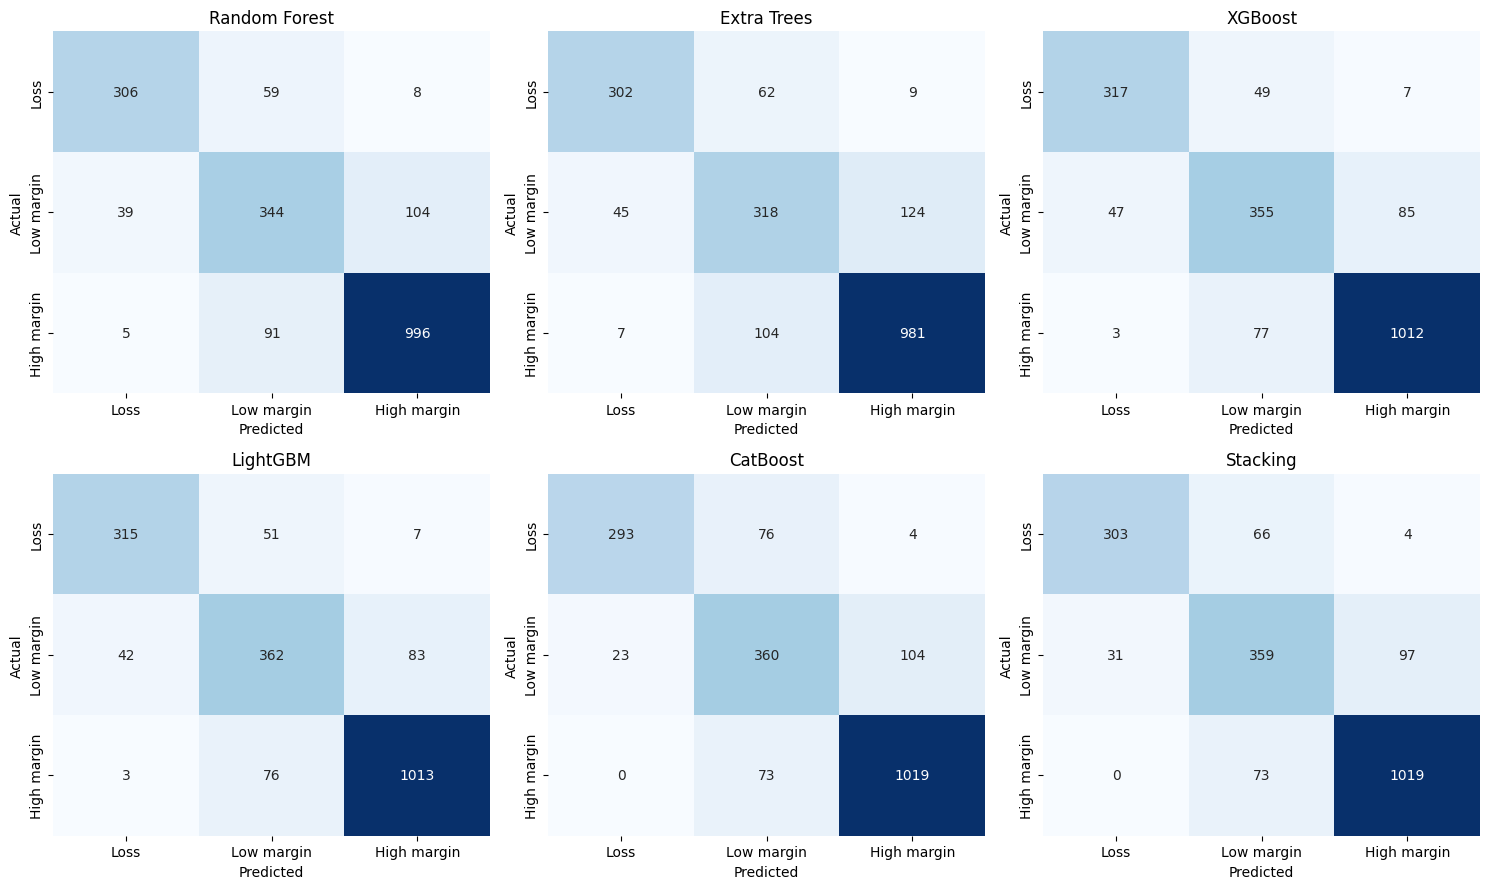

In [18]:
# Confusion matrix for every model
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, (pred, proba)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 16. ROC Curve & AUC Score

The ROC curve shows how well each model separates the classes.
A higher AUC (closer to 1.0) means better performance.

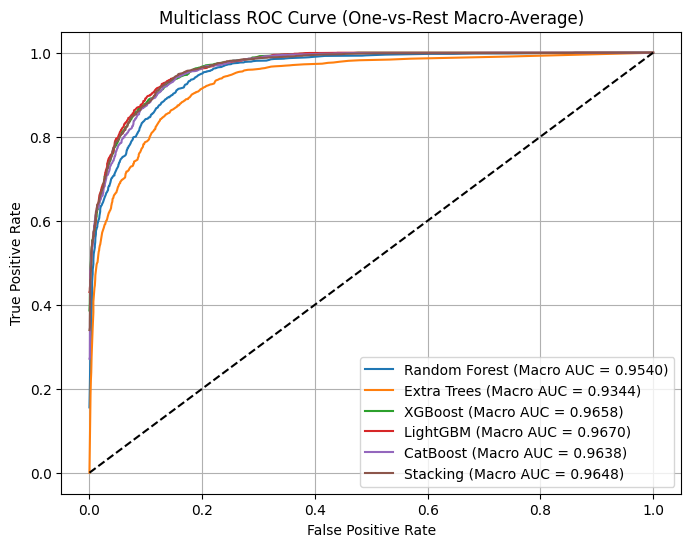

In [20]:
# ROC curve + AUC for all six models (One-vs-Rest Macro-Average)
plt.figure(figsize=(8, 6))

# Binarize the target classes for One-vs-Rest calculation
n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for name, (pred, proba) in models.items():
    # Interpolate ROC curves across all classes to compute the macro-average
    all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], proba[:, i])[0] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr /= n_classes
    macro_auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")

    plt.plot(all_fpr, mean_tpr, label=f"{name} (Macro AUC = {macro_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest Macro-Average)")
plt.legend()
plt.grid(True)
plt.show()